# 全局联邦学习算法对比分析 (Global FL Analysis)

本 Notebook 用于对比分析传统的全局联邦学习算法（如 FedAvg, FedProx, Scaffold 等）在相同实验配置下的性能表现。

In [4]:
import os
import sys
import torch
import matplotlib.pyplot as plt

# 添加项目根目录到路径
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from plot.utils import load_plot, load_plot_all_runs, ResultLoader

In [ ]:
# --- 实验组定义 ---
experiments = {
    # 基础算法
    "FedAvg": ("fedavg", {}),
    "FedProx": ("fedprox", {"mu": 0.01}),
    "Scaffold": ("scaffold", {"global_lr": 1.0}),
    "FedDyn": ("feddyn", {"alpha_coef": 0.1}),

    # 进阶/特征对齐算法
    "FedProc": ("fedproc", {}),
    "FedFM": ("fedfm", {"mu": 1.0}),
    "MOON": ("moon", {"mu": 0.01, "tau": 0.5}),
    "FedLSA": ("fedlsa", {"lambda_com": 0.1, "alpha_sep": 0.1, "server_epochs": 10})
}

# --- 通用参数 ---
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "rounds": 200,
    "lr": 0.01,
    "batch_size": 64
}

loader = ResultLoader(base_dir="../results_ray")

Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
FedAvg               |         65.5833 |         65.3617
FedProx              |         65.4083 |         65.1508
Scaffold             |         66.4917 |         65.9833
FedDyn               |         65.2750 |         64.1975
FedProc              |         55.5833 |         52.2575
FedFM                |         62.2167 |         59.5517
MOON                 |         65.1000 |         64.8742
FedLSA               |         24.5750 |         10.0000
-----------------------------------------------------------------


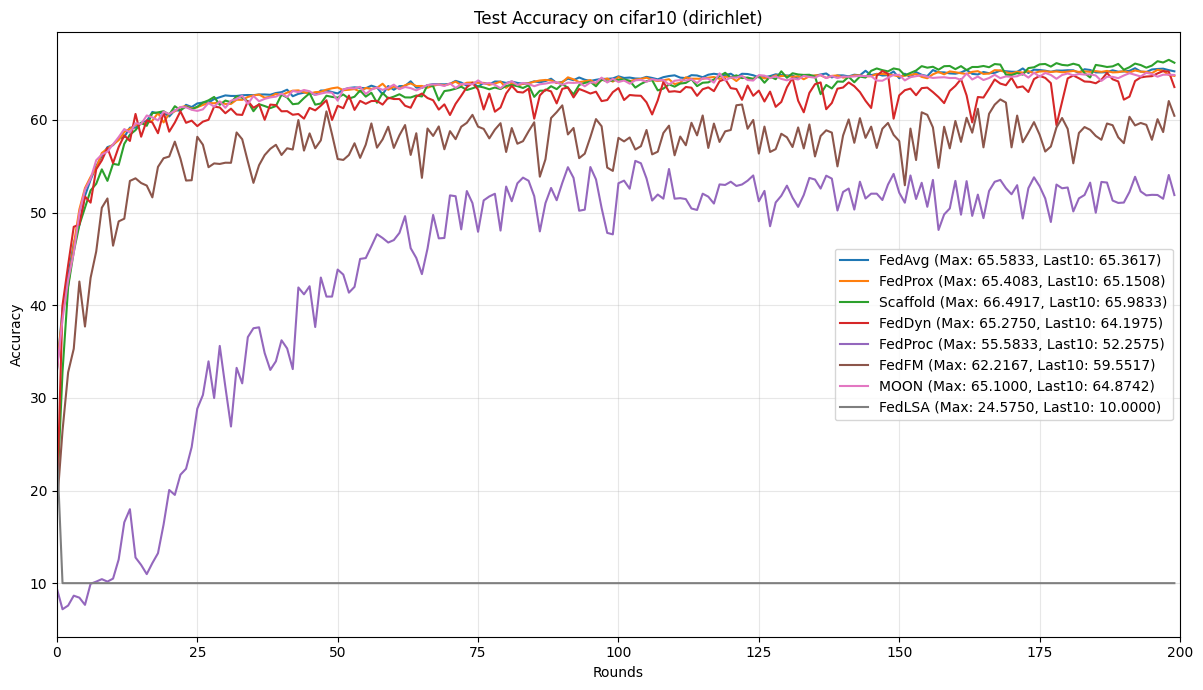

In [7]:
# 1. 加载并绘制曲线 (Run 0)
load_plot(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=200
)

In [8]:
# 2. 统计所有 Run 的平均性能
load_plot_all_runs(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=200
)


Summary of ALL RUNS (Mean ± Std):
---------------------------------------------------------------------------
Algorithm                 |              Max Acc |          Last 10 Avg
---------------------------------------------------------------------------
FedAvg                    |  65.2417 ± 0.3524  |  64.8952 ± 0.4071  (5 runs)
FedProx                   |  65.1467 ± 0.2800  |  64.8503 ± 0.2790  (5 runs)
Scaffold                  |  65.6317 ± 0.5596  |  65.0507 ± 0.7351  (5 runs)
FedDyn                    |  64.9017 ± 0.2478  |  63.4442 ± 0.6011  (5 runs)
FedProc                   |  54.0950 ± 0.7732  |  51.3200 ± 0.8061  (5 runs)
FedFM                     |  61.4717 ± 0.7523  |  58.5288 ± 0.9137  (5 runs)
MOON                      |  64.7600 ± 0.3902  |  64.4790 ± 0.4231  (5 runs)
FedLSA                    |  23.8233 ± 0.4598  |  10.0000 ± 0.0000  (5 runs)
